In [5]:
import os
os.chdir("/content")
!rm -rf STAT-7220- Applied-Experimental-Design


# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "djuarez7-KSU"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
   print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW2"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

⚠️ Found existing folder 'STAT-7220-Applied-Experimental-Design'. Skipping clone to avoid nesting.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW2


# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: October 3, 2025**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer:**

Identify how different teaching methods impact the score results of undergrads students on the worshop about hypothesis testing basics.

**Question 2.** Specify the outcome variable

**Answer:**

The outcome variable will be the score result.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Answer:**

The *independent variable (IV)* is the different **teaching methods** that in our case is a categorical and nominal variable with the values:

-Direct Instruction.

-Inquiry-Based Learning.

-Collaborative Learning.

The *lurking variables* could be:

- Student's prior levels of knowledge on hypothesis testing.

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Answer:**

Since our experiment include the variable **Prior Knowledge** (*high and low*) make the units not homogeneous, and that's why Random Block Design (*RBD*) is appropiate for the experiment.

Therefore, Completely Randomized Design (*CRD*) isn't appropiate because our units aren't homogeneous and we have variation.


**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer:** $$ H_0: \mu_{\text{tm1}} = \mu_{\text{tm2}} = \mu_{\text{tm3}} $$

$$ H_1: \text{At least one pair of means differ substantially} $$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer:**

After checking the initial EDA and creating a visualization, I can infere that the *null hypothesis* isn't supported for the boxplots; since, we can see slighty overlapping between some groups but not in all of them, which potentially indicates that all the means differ from each teaching method.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
High            Collaborative    90.927  7.970758
                Direct           76.998  6.125899
                Inquiry          88.624  5.316835
Low             Collaborative    82.176  8.168793
                Direct           73.659  6.623811
                Inquiry          81.903  5.984395


Text(0.5, 1.0, 'Effect of Teaching Methods on Data Science course Scores')

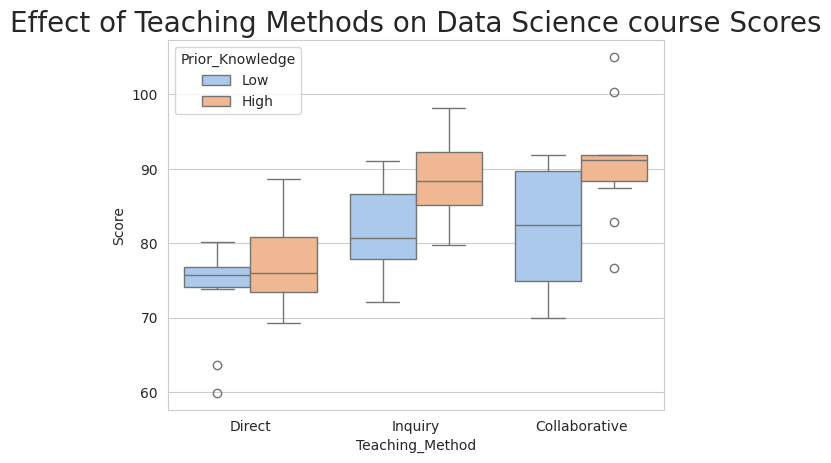

In [8]:
#Import the neccesary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Load the dataset
dst = pd.read_excel('Data Science Teaching Method.xlsx')

#Check dataset
print(dst.info())

#EDA means and standard deviations
#using our blocking factor --> Prior Knowledge
# and our IV --> Teaching Method
stats = dst.groupby(['Prior_Knowledge','Teaching_Method'])['Score'].agg(['mean', 'std'])
print(stats)

#Plot to have a vizualitation
sns.set_style('whitegrid')

sns.boxplot(
    data =  dst,
    x = 'Teaching_Method',
    y = "Score",
    hue = 'Prior_Knowledge',
    palette= 'pastel'
)

plt.title("Effect of Teaching Methods on Data Science course Scores",
          loc = 'center',
          fontsize = 20)


**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Answer:**

Since the *p-value* of the Shapiro-Wilk test is grater than *0.05*, we fail to reject the null hypothesis so normality assumption is met for this experiment.

                      sum_sq    df          F    PR(>F)
Teaching_Method  1508.792653   2.0  16.525296  0.000002
Prior_Knowledge   589.756202   1.0  12.918801  0.000687
Residual         2556.456163  56.0        NaN       NaN


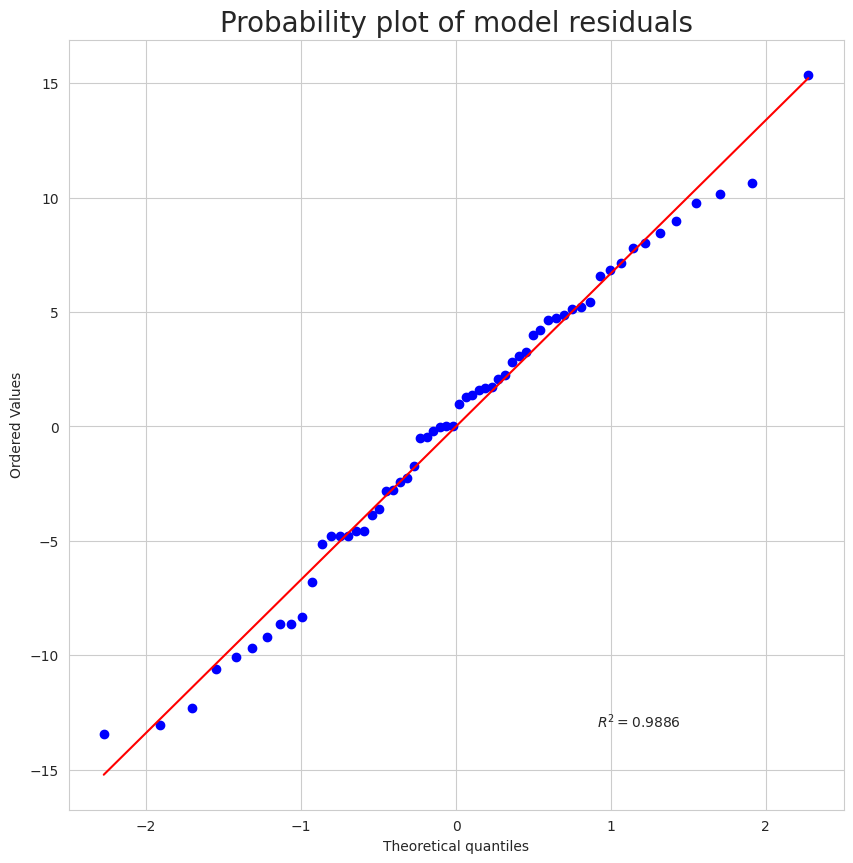

ShapiroResult(statistic=np.float64(0.9844685588485161), pvalue=np.float64(0.6424220730040224))


In [11]:
#ANOVA MODEL
model = ols('Score~Teaching_Method+Prior_Knowledge', data = dst).fit()

#Print ANOVA table
print(sm.stats.anova_lm(model,typ = 2))

#For normality testing we need the scipy library
import scipy.stats as stats

#let's get the residuals
res =  model.resid

#Plot for normality
fig = plt.figure(figsize= (10, 10))
ax = fig.add_subplot(111)

normality_plot, stat = stats.probplot(res, plot= plt, rvalue= True)
ax.set_title("Probability plot of model residuals", fontsize= 20)
ax.set

plt.show()

## S-W Test ##

print(stats.shapiro(res))


**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer:**

We can see in the plot that all the vertical lines are similar height as well are randomly scaterred around 0, meaning that the residuals across groups are consistent and not drastically different.

Also, the plot presented that is not outlier in the dataset, and the Breusch Pagan test *p-value* is grather  than *0.05*, for all these reasons we failed to reject the null hypothesis for the homogeneity assumption test.



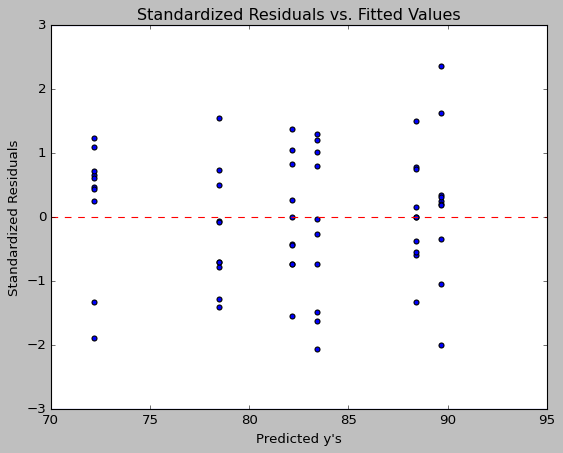

F-statistic: 1.3636907328188852
F p-value: 0.2632703901501631


In [13]:
#Check Homogeneity

# Obtain Standardized Residuals

standardized_residuals = model.get_influence().resid_studentized_internal

# Get the fitted values

fitted_values = model.fittedvalues

## Plot

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test library
from statsmodels.stats.diagnostic import het_breuschpagan

#B-P Test

bp_test = het_breuschpagan(model.resid,model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Answer:**

Since $F(2,56) = 16.52$  and $p < 0.001$, we would say that our data more strongly support the alternative hypothesis for the test.


In [14]:
#Extract value from the ANOVA table
print(sm.stats.anova_lm(model,typ=2))

                      sum_sq    df          F    PR(>F)
Teaching_Method  1508.792653   2.0  16.525296  0.000002
Prior_Knowledge   589.756202   1.0  12.918801  0.000687
Residual         2556.456163  56.0        NaN       NaN


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer:**

Since the data and the inferential analysis strongly support the **Alternative Hypothesis**, meaning that at least one group of Teaching Methods differ from each other the Tukey's HDS post-hoc test could be performed.

The test results, displays that the Direct Teaching Method mean differ from the Collaborative and Inquiry methods.

In [15]:
#Import neccesary library for pairwise_tukeyhsd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dst['Score'], groups=dst['Teaching_Method'],
                                 alpha=0.05)

print(tukey_result)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -11.223    0.0 -16.8766 -5.5694   True
Collaborative Inquiry   -1.288 0.8478  -6.9416  4.3656  False
       Direct Inquiry    9.935 0.0003   4.2814 15.5886   True
-------------------------------------------------------------


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

**Answer:**

We can see that just two of the p-values are less than 0.05, which would indicate that one the score group means may not differ substantially from the other in this population.

As we saw, people in the Direct Method group had the greatest group mean, followed by Inquiry, while Collaborative respect to Inquiry may not have substantially difference between their means.

**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Question 2.** Specify the outcome variable

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations of this experiment.